In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
df=pd.read_csv("Zomato-data-.csv")
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [3]:
def HandelRate(value):
    value=str(value).split("/")
    value=value[0]
    return float(value)
df["rate"]=df["rate"].apply(HandelRate)
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 8.2 KB


In [5]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

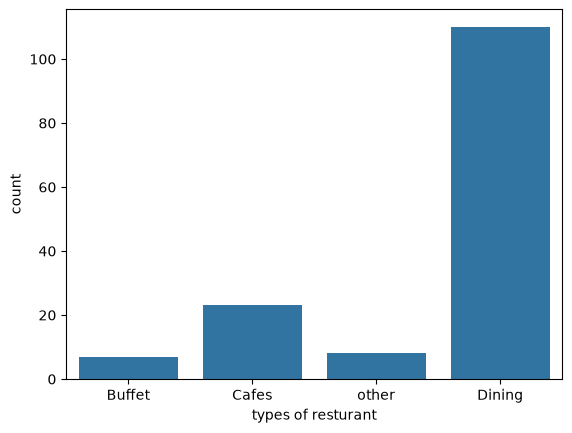

In [8]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("types of resturant")
plt.show()

As we can see above the resturants fall under the dining category 

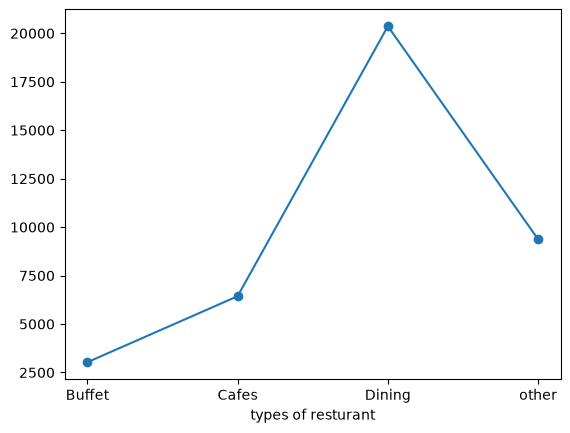

In [10]:
grouped_data=df.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes':grouped_data})
plt.plot(result,marker='o')
plt.xlabel("types of resturant")
plt.show()

Dining category resturants are also more popular

In [11]:
max_votes=df['votes'].max()
resturant=df.loc[df["votes"]==max_votes,'name']
print("Resturant with the highest votes: ")
print(resturant)


Resturant with the highest votes: 
38    Empire Restaurant
Name: name, dtype: str


<Axes: xlabel='online_order', ylabel='count'>

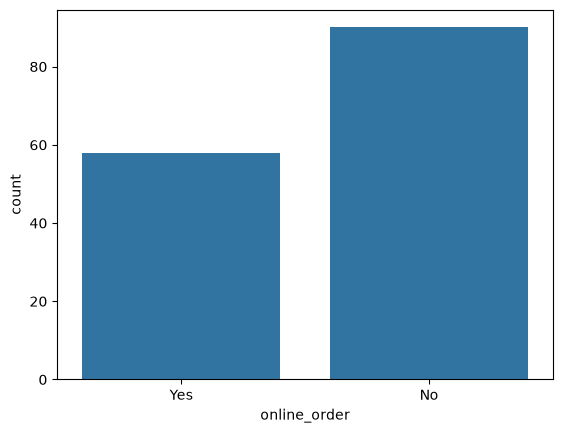

In [12]:
sns.countplot(x=df["online_order"])

majority of resturants do not acept online orders 

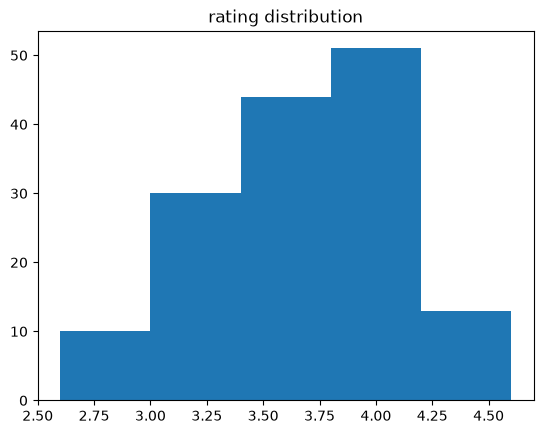

In [15]:
plt.hist(df["rate"],bins=5)
plt.title("rating distribution")
plt.show()

majority of the resturant recieved rating between 3.5 to 4

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

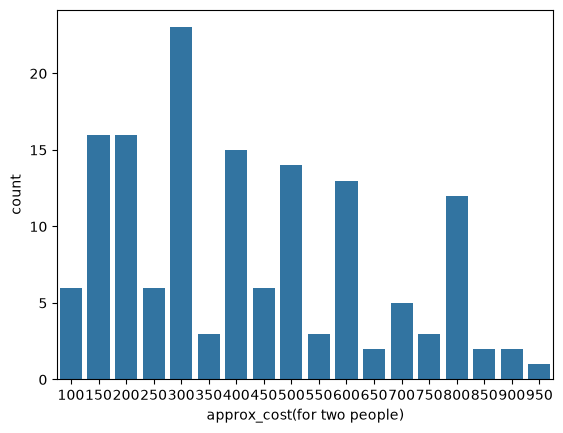

In [16]:
couple=df["approx_cost(for two people)"]
sns.countplot(x=couple)

the approximate cost for majrity of resturant for two people is 300

<Axes: xlabel='online_order', ylabel='rate'>

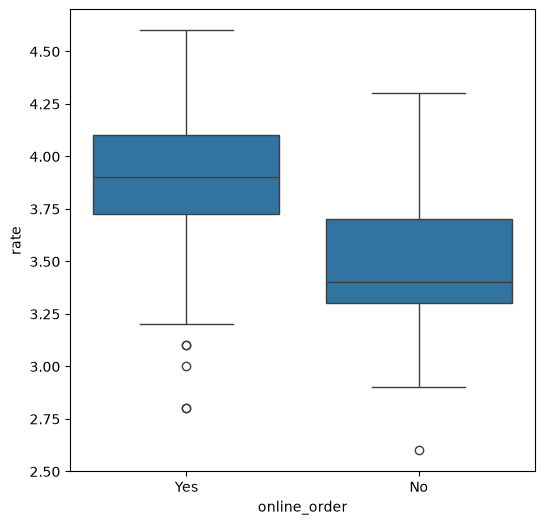

In [18]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = df)

Offline orders received lower ratings in comparison to online orders which obtained excellent ratings

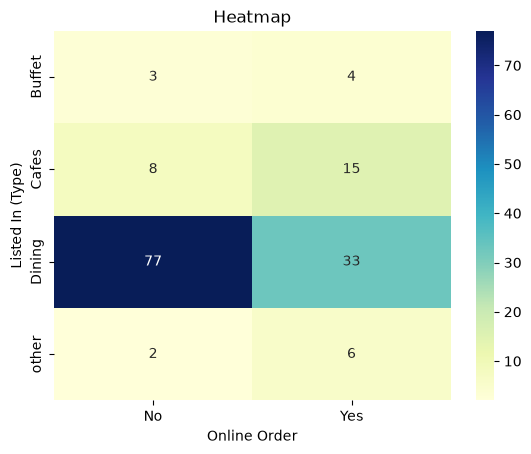

In [19]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

With this we can say that dining restaurants primarily accept offline orders whereas cafes primarily receive online orders. This suggests that clients prefer to place orders in person at restaurants but prefer online ordering at cafes.